# Collection Design

**Vehicle Collection**  
It stores the vehicle's static master data and owner information

* Schema  
```
{
    car_plate: String
    owner_name: String
    owner_addr: String
    vehicle_type: String
    registration_date: Date
}
```

* Sample document  
```json
{
    "car_plate": "ABC123",
    "owner_name": "Example Name",
    "owner_addr": "Example Address",
    "vehicle_type": "Sedan",
    "registration_date": ISODate("2024-01-01T00:00:00Z")
}
```

* Index  
```
{ "car_plate": 1 }
```
> Supports fast lookups when querying vehicle information by car plate, which is the primary access pattern for owner verification and violation correlation.

* Shard-key  
car_plate

> High cardinality ensures data is evenly distributed across shards. Most queries filter by car_plate (e.g., "find all violations for this car"), enabling targeted shard access

* Retention  
Permanently retained  

> Vehicle registration and owner information represents master data that must be retained indefinitely for legal and audit purposes. There is no regulatory requirement to expire this data.


**Camera Collection**  
Stores static reference data for traffic cameras, including location, highway position, and speed limit.

* Schema  
```
{
    camera_id: Int
    location: Point
    position: Double
    speed_limit: Int
}
```

* Sample document  
```json
{
      "camera_id": 1,
      "location": { 
          "type": "Point", 
          "coordinates": [102.6601002, 2.157730731] 
      },
      "position": 152.5,
      "speed_limit": 110
}
```

* Indexes  
`{ "camera_id": 1 }`，`{ "location": "2dsphere" }`

> Primary lookup index for joining violation records to camera metadata; Enables geospatial queries


* Shard-key  
Not applicable. 

> Collection contains only 3 static records. Sharding would introduce unnecessary distribution overhead with no performance benefit.


* Retention  
Permanently retained

> Camera locations and speed limits are static infrastructure metadata that never changes. No expiration required.


**Violation Collection**  
Store detected speeding behavior. To meet the "daily merge"  requirement, use `car_plate` + `date` as the primary key.

* Schema  
```
{
    car_plate: String
    date: Date (Only retain the date portion)
    violations: Array
}
```

* Sample document  
```json
{
     "car_plate": "ABC123",
     "date": ISODate("2024-01-01T00:00:00Z"),
     "violations": [
         {
             "violation_type": "INSTANTANEOUS",
             "camera_id_start": 1,
             "camera_id_end": 1,
             "timestamp_start": ISODate("2024-01-01T08:00:04Z"),
             "timestamp_end": ISODate("2024-01-01T08:00:04Z"),
             "speed_reading": 125.0
         },
         {
             "violation_type": "AVERAGE",
             "camera_id_start": 1,
             "camera_id_end": 2,
             "timestamp_start": ISODate("2024-05-01T14:30:00Z"),
             "timestamp_end": ISODate("2024-05-01T14:35:00Z"),
             "speed_reading": 115.0
         }
     ]
}
```

* Index  
```
{ "car_plate": 1, "date": 1 }
```

> Supports daily lookup: E.g."find all violations for car ABC123 on 2024-01-01"


* Shard-key  
car_plate

> High cardinality ensures even distribution; most queries filter by car_plate, enabling targeted shard access.


* Retention  
Set a TTL index, for example, `{ "date": 1 }`, `expireAfterSeconds: 157680000` (retain for 5 years). 

> The TTL index automatically purges expired documents, reducing storage costs and manual maintenance overhead.

# Collection Relationship

* **Vehicle <-> Violation (1:N):** A vehicle may have multiple traffic violations at different times.
* **Camera <-> Violation (1:N):** One camera can record traffic violations by multiple vehicles.

**Why we use Embedding in Violation?**  

Storing car_plate in a violation record references the vehicle  collection, while storing a list of violation events inside a daily
document is embedding.

* **Read/Write Patterns**  
    * Write: Traffic flow is high-concurrency and continuous. Through embedding, we can leverage MongoDB's `$push` operator in conjunction with `upsert: true` for atomic updates. This means that for each violation detected by Spark, only one database request is needed to complete the "find record for the day -> insert into array" operation, significantly reducing database load.

    * Read: The typical business scenario is "querying all violations for a specific vehicle on a specific day." Since the data is embedded in the same document, MongoDB only needs to perform a single disk seek to retrieve the entire day's data, avoiding multiple I/O operations.
    
* **Trade-off: Duplication vs. Join Cost**
    * Avoid Joins: If each traffic violation is stored as a separate document, querying a vehicle's entire day's records would require a `$lookup` (join query) or multiple queries. Joins are extremely expensive for large datasets.

    * Control Duplicates: We do not embed detailed vehicle owner information (such as address and name), but only the camera_id and violation details. Detailed vehicle owner information is referenced through the car_plate. This leverages the speed of embedding while avoiding significant duplication of static data (vehicle owner information).
    
* **Consistency Requirements**  
    * Atomicity: In MongoDB, modifications to a single document are atomic. By embedding multiple violations for the same day into a single document, we can ensure that the "Daily Violation Statistics" will not suffer from data loss or corruption during concurrent writes.

# Streaming Join Logic

**Workflow Diagram**

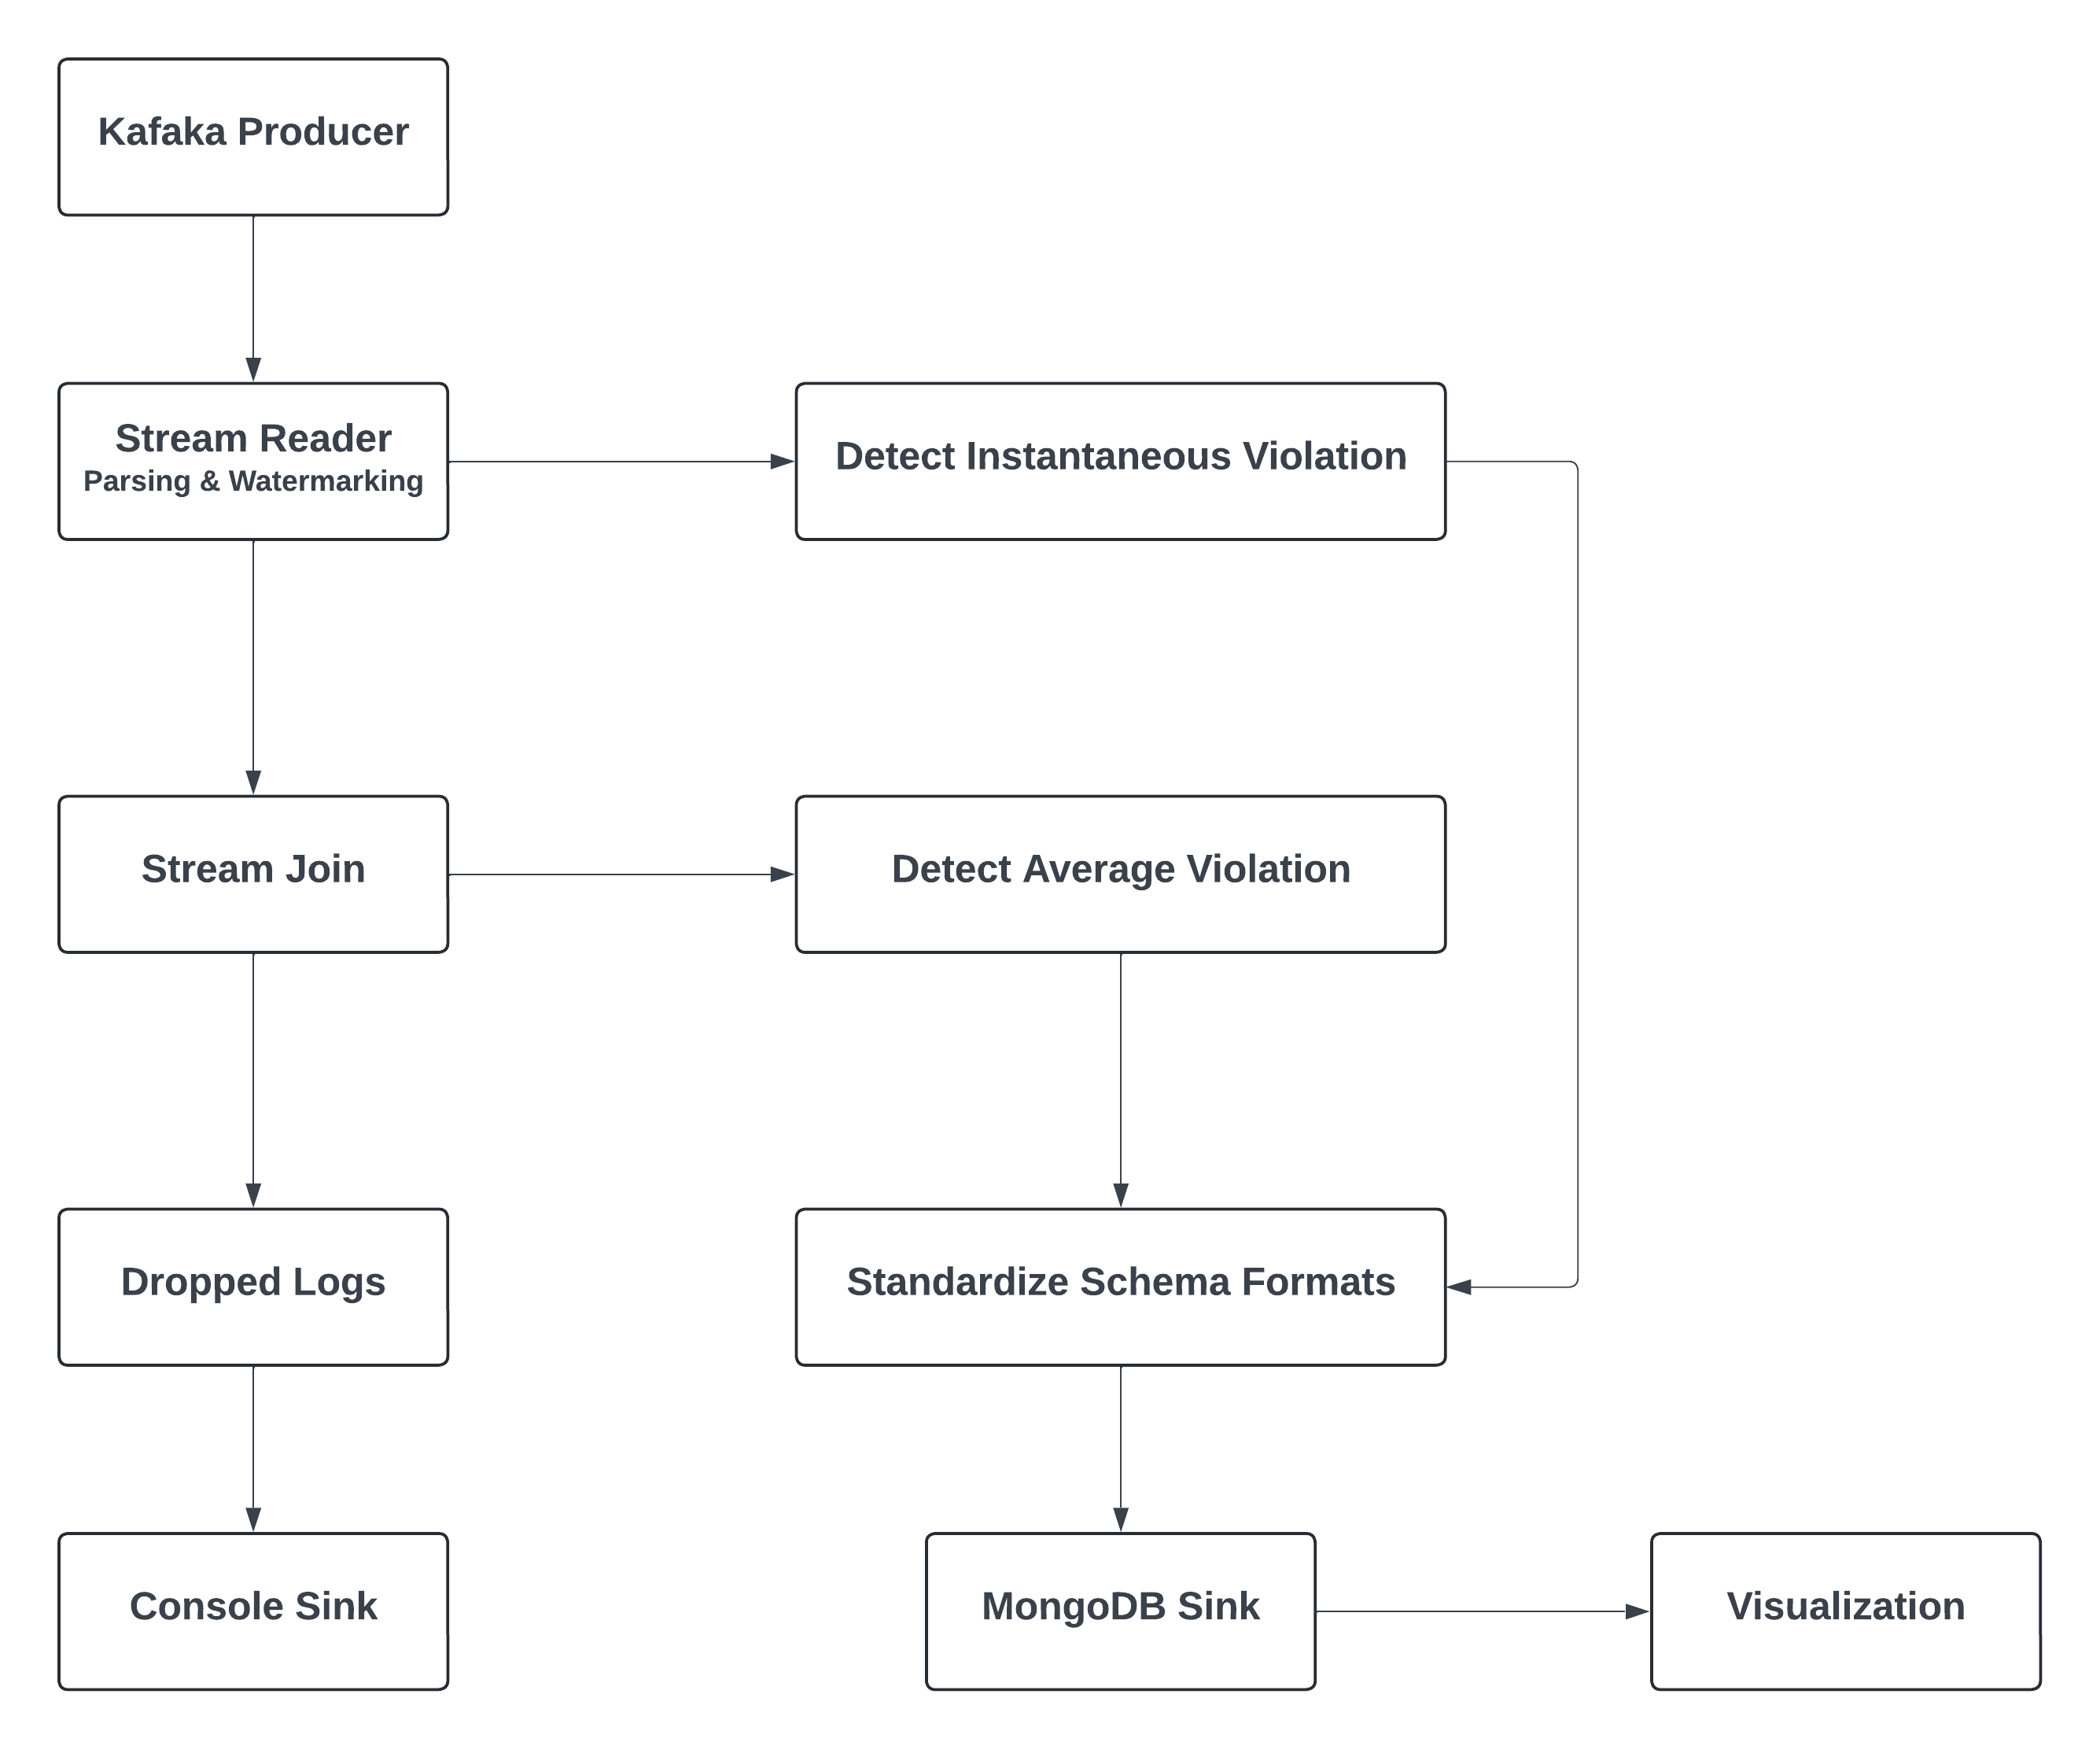

**How are the Spark streams parsed?**

Spark reads data from Kafka and performs two processing steps:

* Format parsing: Converts the binary data from Kafka into text, then parses it into structured data using a fixed format (schema).

* Time conversion: Converts the original time string into a time type that Spark can recognize, enabling time-based processing.


**How does the stream join work?**

Two independent joins were performed:

* Join 1: Segment A (A → B)  
A Left Join is performed on the streams from camera A and camera B. Matching conditions:

    * Same car (same car plate)
    * A's time < B's time ≤ A's time + 60 seconds

The purpose of the Left Join: To retain all records from A. If B does not match within 60 seconds, the fields on B's side will be NULL.

* Join 2: Segment B (B → C)  
A Left Join is performed on the streams from camera B and camera C. Matching conditions:

    * Same car (same car plate)
    * B's time < C's time ≤ B's time + 60 seconds

Similarly, a Left Join is used to retain all records from B.


**How do you calculate average speed?**

After determining the time it takes for a vehicle to pass between the two cameras:

* Travel time (hours) = (End time - Start time) ÷ 3600 seconds
* Average speed = Fixed distance ÷ Travel time

If the calculated speed exceeds the ending camera speed limit, it will be marked as a violation.


**How do we handle late, unmatched, or invalid records?**

Use a Left Join. If a vehicle enters the start camera but doesn't appear at the end camera within 10 minutes:

* The end-related fields will be NULL.
* This record will be marked as EXPIRED_UNMATCHED and then sent to a special log.


**How do we write to MongoDB?**

Write using foreachBatch:

* Daily merging: Using (Car plate, date) as a unique identifier for updates.
* Preventing duplicates (idempotency): Use `$addToSet` instead of `$push`. MongoDB automatically ignores duplicates of the same record.
* High performance: Send a batch of data at once (bulk_write), using only one network request.
* Indexes:
    * Composite index {car plate, date} — speeds up queries.
    * TTL index — automatically deletes old data after 5 years, requiring no manual maintenance.

**Table of important parameters**
|**Parameter**|**Example**|**Purpose**|
|:-----------:|:---------:|:---------:|
|Producer sleep time|10 seconds|Controls event publishing rate|
|Watermark|10 minutes|Limits retained streaming state|
|Join window|60 seconds|Defines valid camera-to-camera travel time|
|Starting Offsets|`latest`|Only process the latest real-time messages after startup.|
|MongoDB daily key| `car_plate + date`|Merges same-day violations|
|MongoDB TTL Duration|157680000 seconds|Data retention strategy|
|Data retention strategy|3 attempts|Perform a maximum of 3 retries|

In [ ]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, expr, from_json, to_timestamp, udf, lit, to_date, when, unix_timestamp
from pyspark.sql.types import StructField, StructType, StringType, IntegerType, DoubleType, BooleanType

import pandas as pd
import math

In [ ]:
# MongoDB host address
HOST_IP = "host.docker.internal"

# Kafka bootstrap server address
KAFKA_BOOTSTRAP_SERVERS = f"{HOST_IP}:9092"

# Jar Packages
SPARK_PACKAGES = (
    "org.apache.spark:spark-streaming-kafka-0-10_2.12:3.3.0,"
    "org.apache.spark:spark-sql-kafka-0-10_2.12:3.3.0"
)

# Pass packages to PySpark submit arguments
os.environ["PYSPARK_SUBMIT_ARGS"] = f"--packages {SPARK_PACKAGES} pyspark-shell"

# Spark Session Creation
spark = (
    SparkSession.builder
    .master("local[*]")                                          # Run locally with all CPU cores
    .appName("AWAS-Traffic-Monitoring")                          # Application name for UI
    .config("spark.sql.shuffle.partitions", "2")                 # Reduce partitions for small local tests
    .config("spark.streaming.stopGracefullyOnShutdown", "true")  # Finish processing before shutdown
    .getOrCreate()                                               # Reuse existing session or create new
)

# Suppress verbose INFO logs, only show WARN and ERR
spark.sparkContext.setLogLevel("WARN")

print("Spark session started.")

## Schema Definition

This code defines the schema. This step is crucial when Spark processes Kafka data because the data from Kafka is just a "raw byte stream," and Spark needs this "blueprint" to understand how to parse these bytes into a table with column names.

In [ ]:
# Define the event schema (which must be exactly the same as the format sent by the Producer).
event_schema = StructType([
    StructField("event_id", StringType()),
    StructField("batch_id", IntegerType()),
    StructField("car_plate", StringType()),
    StructField("camera_id", IntegerType()),
    StructField("timestamp", StringType()),
    StructField("speed_reading", DoubleType()),
    StructField("producer_id", StringType())
])

## Kafka Stream Reader

**Watermark Assumptions**
* Assumption: A maximum latency of 10 minutes is allowed in the Kafka data stream.
* Impact: If data from camera B arrives at Spark 11 minutes after it was generated at camera A, it will be discarded and will not be included in the join.

In [ ]:
def read_camera_stream(topic_name):
    '''
    Read streaming data from a Kafka topic and parse camera event records.

    Processing steps:
        1. Reads streaming data from Kafka using Spark Structured Streaming
        2. Converts the Kafka `value` (binary) to a JSON string
        3. Parses the JSON string using `event_schema`
        4. Converts the `timestamp` field to `event_time` as Spark TimestampType
        5. Applies a 10-minute watermark for late data handling

    Args:
        topic_name (str): The name of the Kafka topic to subscribe to
    '''
    return (
        spark.readStream
        .format("kafka")
        .option("kafka.bootstrap.servers", KAFKA_BOOTSTRAP_SERVERS)
        .option("subscribe", topic_name)
        .option("startingOffsets", "latest")
        .load()
        .selectExpr("CAST(value AS STRING) AS json_value")
        .select(from_json(col("json_value"), event_schema).alias("data"))
        .select("data.*")
        .withColumn("event_time", to_timestamp(col("timestamp")))
        .withWatermark("event_time", "10 minutes") 
    )


camera_a_stream = read_camera_stream("camera-events-A")
camera_b_stream = read_camera_stream("camera-events-B")
camera_c_stream = read_camera_stream("camera-events-C")

print("Kafka streams initialized for Camera A, B, and C.")

## Detect Instantaneous Violations

By configuring speed limits using static cameras, the system can detect Instantaneous Violations in real time from three camera streams and aggregate and output all violation records.

In [ ]:
camera_df_static = pd.read_csv('../data/camera.csv')

# Define a speed limit dictionary
speed_limits = camera_df_static.set_index('camera_id')['speed_limit'].to_dict()

# Define the detection function and register it as a UDF
def is_speeding(camera_id, speed):
    """
    Check if a vehicle's speed exceeds the camera's speed limit.

    Args:
        camera_id: Camera identifier used to look up speed limit
        speed: Vehicle speed in km/h

    Returns:
        True if speed > limit, False otherwise (unknown cameras return False)
    """
    return speed > speed_limits.get(camera_id, float("inf"))

is_speeding_udf = udf(is_speeding, BooleanType())

# Apply detection logic to each of the three streams
instant_violations_A = camera_a_stream.filter(
    is_speeding_udf(col("camera_id"), col("speed_reading"))
)

instant_violations_B = camera_b_stream.filter(
    is_speeding_udf(col("camera_id"), col("speed_reading"))
)

instant_violations_C = camera_c_stream.filter(
    is_speeding_udf(col("camera_id"), col("speed_reading"))
)

# Combine all three streams into one
instant_violations = instant_violations_A.union(
    instant_violations_B
).union(
    instant_violations_C
)

```
instant_violations = {
    "event_id",
    "batch_id",
    "car_plate",
    "camera_id",
    "timestamp",
    "speed_reading",
    "producer_id",
    "event_time"
}
```

## A-B & B-C Stream Join

**Time Window Assumptions**  
* Assumption: A normally traveling vehicle will traverse the road segment in no more than 60 seconds.

* Business Basis: Based on observations of camera_event datasets, most vehicles traverse the road between two cameras within 60 seconds.

In [ ]:
# Segment A -> B
# Match vehicles that passed camera A then camera B within 60 seconds
joined_ab = (
    camera_a_stream.alias("a")
    .join(
        camera_b_stream.alias("b"),
        expr("""
            a.car_plate = b.car_plate AND
            a.event_time < b.event_time AND
            b.event_time <= a.event_time + interval 60 seconds
        """),
        "left" # Left join to keep all A records
    )
    .select(
        col("a.car_plate").alias("car_plate"),
        col("a.camera_id").alias("camera_id_start"),
        col("b.camera_id").alias("camera_id_end"),
        col("a.event_time").alias("timestamp_start"),
        col("b.event_time").alias("timestamp_end"),
        col("a.speed_reading").alias("speed_start"),
        col("b.speed_reading").alias("speed_end")
    )
)

# Segment B -> C
# Match vehicles that passed camera B then camera C within 60 seconds
joined_bc = (
    camera_b_stream.alias("b")
    .join(
        camera_c_stream.alias("c"),
        expr("""
            b.car_plate = c.car_plate AND
            b.event_time < c.event_time AND
            c.event_time <= b.event_time + interval 60 seconds
        """),
        "left" # Left join to keep all B records
    )
    .select(
        col("b.car_plate").alias("car_plate"),
        col("b.camera_id").alias("camera_id_start"),
        col("c.camera_id").alias("camera_id_end"),
        col("b.event_time").alias("timestamp_start"),
        col("c.event_time").alias("timestamp_end"),
        col("b.speed_reading").alias("speed_start"),
        col("c.speed_reading").alias("speed_end")  
    )
)

Handling of unmatched or expired records

In [ ]:
# Identify and record the status
processed_ab = joined_ab.withColumn(
    "status",
    when(col("camera_id_end").isNull(), "UNMATCHED_OR_EXPIRED")
    .otherwise("MATCHED")
)

# Filter out the "failed" records as Log
dropped_logs_ab = processed_ab.filter(col("status") != "MATCHED")

processed_bc = joined_bc.withColumn(
    "status",
    when(col("camera_id_end").isNull(), "UNMATCHED_OR_EXPIRED")
    .otherwise("MATCHED")
)

# Filter out the "failed" records as Log
dropped_logs_bc = processed_bc.filter(col("status") != "MATCHED")

# Combine all streams into one
dropped_logs = dropped_logs_ab.union(dropped_logs_bc)

```
dropped_logs = {
    "car_plate",
    "camera_id_start",
    "camera_id_end",
    "timestamp_start",
    "timestamp_end",
    "speed_start",
    "speed_end",
    "status"
}
```

## Detect Average Speed Violations

In [ ]:
# Define the Haversine distance calculation function (unit: km).
def calculate_haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points on Earth using the Haversine formula.

    Args:
        lat1, lon1: Latitude and longitude of point 1
        lat2, lon2: Latitude and longitude of point 2

    Returns:
        Distance in kilometers (float)
    """
    R = 6371.0  # The Earth's average radius, measured in kilometers.
    
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    
    a = math.sin(dphi / 2)**2 + \
        math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2)**2
    
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

# Extract coordinates (indices 0, 1, 2 correspond to camera_id 1, 2, 3 respectively).
camA = camera_df_static.iloc[0]
camB = camera_df_static.iloc[1]
camC = camera_df_static.iloc[2]

# Calculate distance & Ending camera limit
dist_A_B = calculate_haversine(camA['latitude'], camA['longitude'], camB['latitude'], camB['longitude'])
dist_B_C = calculate_haversine(camB['latitude'], camB['longitude'], camC['latitude'], camC['longitude'])
camera_B_limit = camB['speed_limit']
camera_C_limit = camC['speed_limit']

Calculate average speed and filter average violations

In [ ]:
# Segment A -> B
ab_with_avg_speed = (
    joined_ab
    # Convert travel time from seconds to hours
    .withColumn(
        "travel_time_hours",
        (unix_timestamp(col("timestamp_end")) - unix_timestamp(col("timestamp_start"))) / lit(3600.0)
    )
    # Calculate average speed = distance / time
    .withColumn(
        "avg_speed",
        lit(dist_A_B) / col("travel_time_hours")
    )
)

# Keep only records where average speed exceeds camera B's speed limit
ab_avg_violations = ab_with_avg_speed.filter(
    col("avg_speed") > lit(camera_B_limit)
)

# Segment B -> C
bc_with_avg_speed = (
    joined_bc
    .withColumn(
        "travel_time_hours",
        (unix_timestamp(col("timestamp_end")) - unix_timestamp(col("timestamp_start"))) / lit(3600.0)
    )
    .withColumn(
        "avg_speed",
        lit(dist_B_C) / col("travel_time_hours")
    )
)

bc_avg_violations = bc_with_avg_speed.filter(
    col("avg_speed") > lit(camera_C_limit)
)

# Combine all streams into one
avg_violations = ab_avg_violations.union(bc_avg_violations)

```
avg_violations = {
    car_plate,
    camera_id_start,
    camera_id_end,
    timestamp_start,
    timestamp_end,
    speed_start,
    speed_end,
    travel_time_hours,
    avg_speed
}
```

# Sink Integration with MongoDB

Step 1: Normalize the data flow based on the defined violation collection schema.

In [ ]:
# 1. Normalize instantaneous violations
mongo_instant = instant_violations.select(
    col("car_plate"),
    to_date(col("event_time")).alias("date"), 
    lit("INSTANTANEOUS").alias("violation_type"),
    col("camera_id").alias("camera_id_start"),
    col("camera_id").alias("camera_id_end"),
    col("event_time").alias("timestamp_start"),
    col("event_time").alias("timestamp_end"),
    col("speed_reading")
)

# 2. Normalize average violations
mongo_avg = avg_violations.select(
    col("car_plate"),
    to_date(col("timestamp_start")).alias("date"), 
    lit("AVERAGE").alias("violation_type"),
    col("camera_id_start"),
    col("camera_id_end"),
    col("timestamp_start"),
    col("timestamp_end"),
    col("avg_speed").alias("speed_reading")
)

# 3. Combine violation stream
all_violations_stream = mongo_instant.union(mongo_avg)

```
all_violations_stream = {
    car_plate,
    date,
    violation_type,
    camera_id_start,
    camera_id_end,
    timestamp_start,
    timestamp_end,
    speed_reading
}
```

Step 2: MongoDB Sink Implementation

In [ ]:
import datetime
import time     
from pymongo import MongoClient, UpdateOne

def write_violations_to_mongo(batch_df, batch_id, clean_before_write=False):
    """
    Write violation records to MongoDB with daily aggregation and deduplication.

    Args:
        batch_df: PySpark DataFrame with violation columns (car_plate, date, violation_type, etc.)
        batch_id: Batch identifier for tracking (not directly used)
        clean_before_write: If True, drops the entire "violations" collection before writing

    Returns:
        None

    Behavior:
        - Groups violations by (car_plate, date) into a single document per day
        - Uses $addToSet to prevent duplicate violations
        - Creates TTL index for 5-year auto-expiration
        - Retries up to 3 times with exponential backoff on failure
    """
    # Initialize connection
    client = MongoClient(
            host=f'{HOST_IP}',
            port=27017
        )
    db = client["traffic_monitoring"] # Get/create the "traffic_monitoring" database.
    
    # Clear old data before each run to avoid duplication.
    if clean_before_write:
        db.drop_collection("violations")
    
    # Get/Create violations collection
    collection = db["violations"]
    
    # Creating a composite index
    collection.create_index([("car_plate", 1), ("date", 1)])
    
    # Retention Policy: TTL Index (5-years automatic expiration)
    # 157,680,000 seconds = 5 years
    collection.create_index([("date", 1)], expireAfterSeconds=157680000)
    
    # Collect current micro-batch
    rows = batch_df.collect()
    
    # If rows is an empty list, the MongoDB connection is closed and the system returns immediately without performing any further writes.
    if not rows:
        client.close()
        return
        
    # Construct a batch operation list
    # Core deduplication and merging logic
    operations = []
    for row in rows:
        # Convert PySpark's date type to Python datetime (so that MongoDB stores it as standard ISODate at 00:00).
        violation_date = datetime.datetime.combine(row.date, datetime.time.min)
        
        # Build a detailed list of individual violations that strictly meets the schema
        violation_detail = {
            "violation_type": row.violation_type,
            "camera_id_start": row.camera_id_start,
            "camera_id_end": row.camera_id_end,
            "timestamp_start": row.timestamp_start, 
            "timestamp_end": row.timestamp_end,     
            "speed_reading": row.speed_reading
        }
        
        # Daily Merge
        # $setOnInsert: Sets these fields only when a new document is inserted. If the document already exists, no changes are made.
        # $addToSet ensures that duplicate appends are not performed when the entire sub-document is identical, guaranteeing idempotency.
        op = UpdateOne(
            {
                "car_plate": row.car_plate, 
                "date": violation_date
            },
            {
                "$setOnInsert": {
                    "car_plate": row.car_plate, 
                    "date": violation_date
                },
                "$addToSet": {
                    "violations": violation_detail
                }
            },
            upsert=True
        )
        
        operations.append(op)
        
    # Batch write and retry mechanism
    max_retries = 3
    for attempt in range(max_retries):
        try:
            if operations:
                # Perform a batch write operation, sending all UpdateOne operations at once.
                # ordered=False: Even if an operation fails, it will continue to attempt subsequent operations, significantly improving write performance.
                collection.bulk_write(operations, ordered=False)
            break 
        except Exception as e:
            print(f"[ERROR] Mongo write failed (Attempt {attempt+1}/{max_retries}): {e}")
            
            # If this is the last attempt, then close the connection and throw an exception.
            if attempt == max_retries - 1:
                client.close()
                raise e
            
            # Otherwise, wait 2^attempt seconds (1 second, 2 seconds, 4 seconds) before retrying.
            time.sleep(2 ** attempt)

    client.close()

db_writer uses update mode to support the transactional 'Daily Merge' business requirement

In [ ]:
db_writer = (
    all_violations_stream.writeStream
    .foreachBatch(write_violations_to_mongo)
    .outputMode("append")
    .option("checkpointLocation", "checkpoints_mongodb_violations")
)

As an additional stream for logging, we define a stream writer for the console sink.

In [ ]:
console_logger = (
    dropped_logs.writeStream
    .outputMode('append')
    .format('console') # Specify the output format as console
)

The final stage binds our calculated violation streams to their respective real-time sinks. 

1. **Triggering Execution**: The `.start()` method invokes the background processing engines for both the MongoDB production database and the diagnostic console logger.
2. **Driver Synchronization**: We implement `awaitTermination()` to force the application to remain active until a failure or termination signal occurs.
3. **Fault-Tolerant Disposal**: A robust exception handling block wraps the execution, ensuring that manual kernel interruptions (Ctrl+C) or streaming queries exceptions are gracefully intercepted to release active cluster resources.

In [ ]:
try:
    print("[INFO] Starting synchronized dual-stream architecture...")
    print("[SINK 1/2] Launching MongoDB Violations Writer...")
    query_db = db_writer.start()

    print("[SINK 2/2] Launching Console Dropped-Records Logger...")
    query_console = console_logger.start()

    # Make the Driver thread wait for the completion of two streams simultaneously.
    query_db.awaitTermination()
    query_console.awaitTermination()
except KeyboardInterrupt:
    print('Interrupted by CTRL-C. Stopped query')
finally:    
    # Safe shutdown logic: stop() is only executed when the stream is successfully initialized and is in an active state.
    if query_db is not None and query_db.isActive:
        query_db.stop()
        print("[SUCCESS] MongoDB Stream writer stopped.")
        
    if query_console is not None and query_console.isActive:
        query_console.stop()
        print("[SUCCESS] Console Logger Stream stopped.")
        
    print("[INFO] Streaming application terminated cleanly.")